# Sentiment Analysis with Doc2Vec
This notebook performs sentiment analysis using Doc2Vec embeddings where each review is treated as a document.

In [8]:
# Setup and imports
import pandas as pd
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

warnings.filterwarnings("ignore")

# Download required NLTK resources
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

# Load the dataset
df = pd.read_csv("Sentiment Analysis Dataset.tsv", sep="\t")
print("Dataset loaded:", df.shape)

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     Missing Authority Key Identifier (_ssl.c:1032)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     Missing Authority Key Identifier (_ssl.c:1032)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     Missing Authority Key Identifier (_ssl.c:1032)>


Dataset loaded: (25000, 3)


## 1. Load and Explore the Dataset

In [9]:
# Basic exploration
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (25000, 3)

First few rows:
       id  sentiment                                             review
0  5814_8          1  With all this stuff going down at the moment w...
1  2381_9          1  \The Classic War of the Worlds\" by Timothy Hi...
2  7759_3          0  The film starts with a manager (Nicholas Bell)...
3  3630_4          0  It must be assumed that those who praised this...
4  9495_8          1  Superbly trashy and wondrously unpretentious 8...

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         25000 non-null  object
 1   sentiment  25000 non-null  int64 
 2   review     25000 non-null  object
dtypes: int64(1), object(2)
memory usage: 586.1+ KB
None

Sentiment Distribution:
sentiment
1    12500
0    12500
Name: count, dtype: int64

Missing Values:
id           0
sentiment    0
review       0
dtype

## 2. Text Preprocessing

In [10]:
# Text preprocessing utilities
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

print("Preprocessing text...")
df['tokens'] = df['review'].astype(str).apply(preprocess_text)
print("Preprocessing complete")
print("Sample tokens:")
print(df['tokens'].head())

Preprocessing text...
Preprocessing complete
Sample tokens:
0    [stuff, going, moment, started, listening, mus...
1    [classic, war, world, timothy, hines, entertai...
2    [film, start, manager, nicholas, bell, giving,...
3    [must, assumed, praised, film, greatest, filme...
4    [superbly, trashy, wondrously, unpretentious, ...
Name: tokens, dtype: object


## 3. Build Doc2Vec Documents

In [11]:
# Build TaggedDocument objects (one review = one doc)
tagged_docs = [TaggedDocument(words=tokens, tags=[i]) for i, tokens in enumerate(df['tokens'])]
print(f"Tagged documents: {len(tagged_docs)}")

Tagged documents: 25000


## 3. Train Doc2Vec Model

In [12]:
# Train Doc2Vec model
print("Training Doc2Vec model...")
doc2vec_model = Doc2Vec(
    vector_size=128,
    window=5,
    min_count=2,
    workers=4,
    dm=1,
    epochs=30,
    seed=42
)

doc2vec_model.build_vocab(tagged_docs)
doc2vec_model.train(tagged_docs, total_examples=doc2vec_model.corpus_count, epochs=doc2vec_model.epochs)

print("Doc2Vec model trained")
print(f"Vocabulary size: {len(doc2vec_model.wv)}")

# Create document embeddings from learned document vectors
X = np.array([doc2vec_model.dv[i] for i in range(len(tagged_docs))])
print(f"Embedding shape: {X.shape}")
print(f"Sample embedding (first 10 values):\n{X[0][:10]}")

Training Doc2Vec model...
Doc2Vec model trained
Vocabulary size: 40665
Embedding shape: (25000, 128)
Sample embedding (first 10 values):
[ 2.2150693  -0.647698   -0.045468   -0.22823909 -0.69206756  0.80570537
 -0.5420143  -0.92448205  0.8577912  -1.0773611 ]


## 4. Train Classification Model (Logistic Regression)

In [13]:
# Prepare labels
y = df['sentiment'].values

# Split data into training and testing sets (80-20 split)
print("Splitting data into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data split completed")
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Train Logistic Regression classifier
print("Training Logistic Regression classifier...")
classifier = LogisticRegression(random_state=42, max_iter=1000)
classifier.fit(X_train, y_train)

print("Classifier trained successfully")

# Make predictions on test set
y_pred = classifier.predict(X_test)

print("\nSample predictions (first 10):")
print(f"Predicted: {y_pred[:10]}")
print(f"Actual:    {y_test[:10]}")

Splitting data into train and test sets...
Data split completed
Training set size: 20000
Testing set size: 5000
Training Logistic Regression classifier...
Classifier trained successfully

Sample predictions (first 10):
Predicted: [1 1 0 0 1 0 0 0 0 1]
Actual:    [1 1 0 0 1 0 1 0 0 1]


## 5. Evaluate Model Performance

MODEL PERFORMANCE METRICS
Accuracy:  0.8576
Precision: 0.8576
Recall:    0.8576
F1-Score:  0.8576


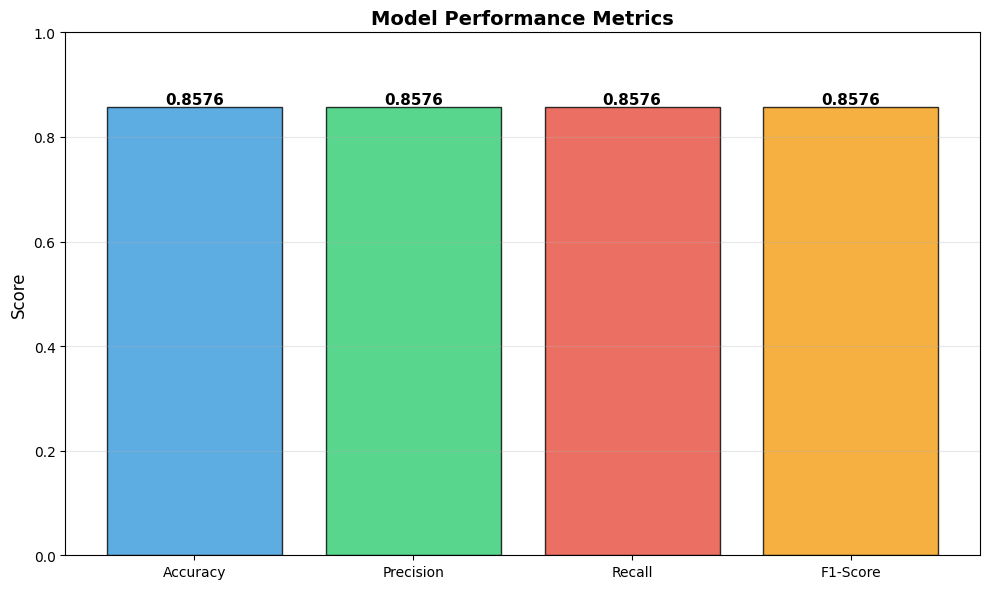

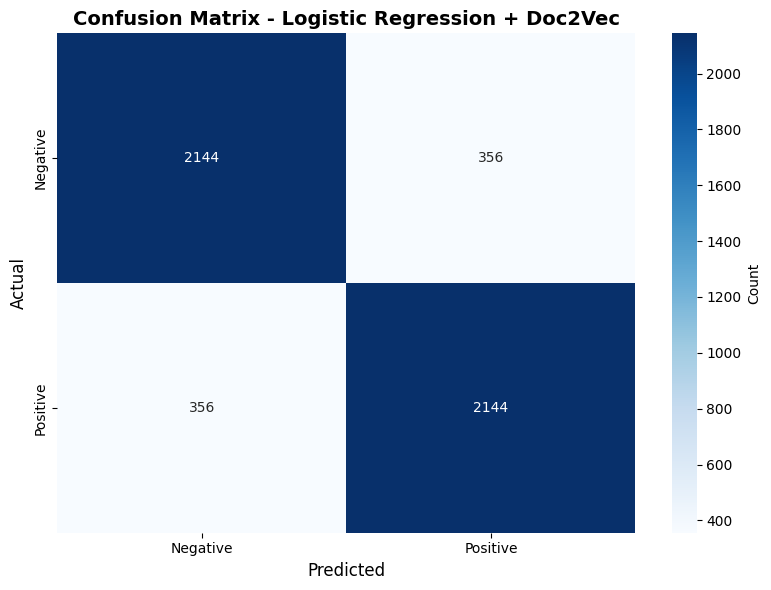

Confusion Matrix:
[[2144  356]
 [ 356 2144]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86      2500
    Positive       0.86      0.86      0.86      2500

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



In [14]:
# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("=" * 50)

# Visualize performance metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, scores, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'], alpha=0.8, edgecolor='black')
plt.ylim(0, 1)
plt.ylabel('Score', fontsize=12)
plt.title('Model Performance Metrics', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for bar, score in zip(bars, scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height,
             f'{score:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Logistic Regression + Doc2Vec', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)

print("\nCLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))
print("=" * 50)

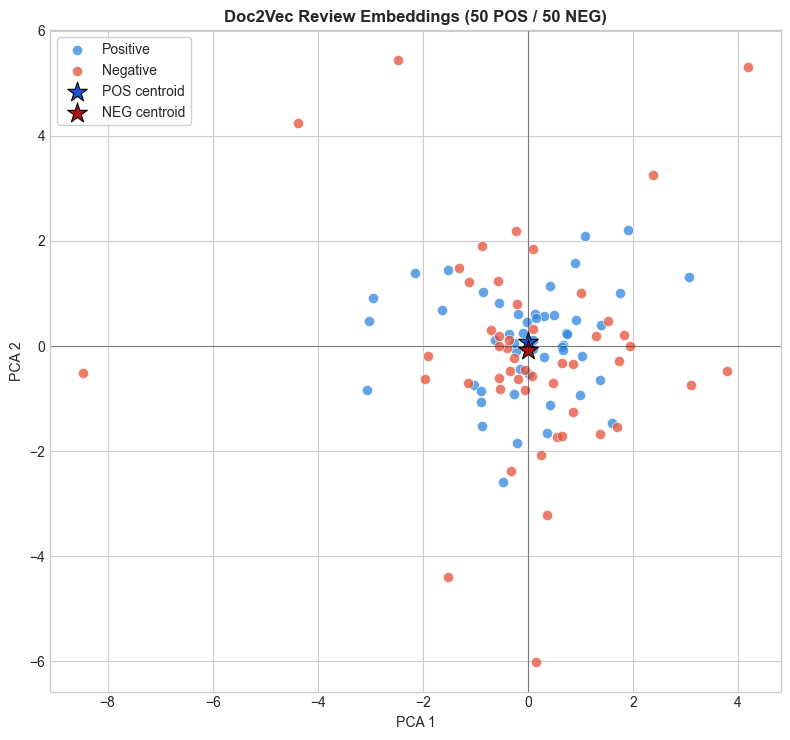

In [19]:
# Visualize Doc2Vec embeddings with PCA (50 POS / 50 NEG)
from sklearn.decomposition import PCA

pos_indices = df.index[df['sentiment'] == 1].to_numpy()
neg_indices = df.index[df['sentiment'] == 0].to_numpy()

pos_count = min(50, len(pos_indices))
neg_count = min(50, len(neg_indices))

rng = np.random.default_rng(42)
pos_sample = rng.choice(pos_indices, size=pos_count, replace=False)
neg_sample = rng.choice(neg_indices, size=neg_count, replace=False)

selected_indices = np.concatenate([pos_sample, neg_sample])
selected_labels = df.loc[selected_indices, 'sentiment'].to_numpy()
selected_vectors = X[selected_indices]

pca = PCA(n_components=2)
doc_vec_2d = pca.fit_transform(selected_vectors)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8.5, 7.5))

pos_mask = selected_labels == 1
neg_mask = selected_labels == 0

ax.scatter(doc_vec_2d[pos_mask, 0], doc_vec_2d[pos_mask, 1],
           s=55, c='#2e86de', alpha=0.75, edgecolors='white', linewidths=0.6,
           label='Positive')
ax.scatter(doc_vec_2d[neg_mask, 0], doc_vec_2d[neg_mask, 1],
           s=55, c='#e55039', alpha=0.75, edgecolors='white', linewidths=0.6,
           label='Negative')

pos_centroid = doc_vec_2d[pos_mask].mean(axis=0)
neg_centroid = doc_vec_2d[neg_mask].mean(axis=0)

ax.scatter(pos_centroid[0], pos_centroid[1], s=220, c='#1f4fd8',
           marker='*', edgecolors='black', linewidths=0.8, label='POS centroid')
ax.scatter(neg_centroid[0], neg_centroid[1], s=220, c='#b31212',
           marker='*', edgecolors='black', linewidths=0.8, label='NEG centroid')

ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)
ax.axvline(0, color='black', linewidth=0.8, alpha=0.4)
ax.set_title('Doc2Vec Review Embeddings (50 POS / 50 NEG)', fontweight='bold')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_aspect('equal', 'box')
ax.legend(frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

## 6. Compare Word2Vec vs Doc2Vec Embeddings (Side-by-Side)

Training Word2Vec model for comparison...
Word2Vec model trained
Vocabulary size: 40665
Word2Vec embeddings shape: (25000, 128)


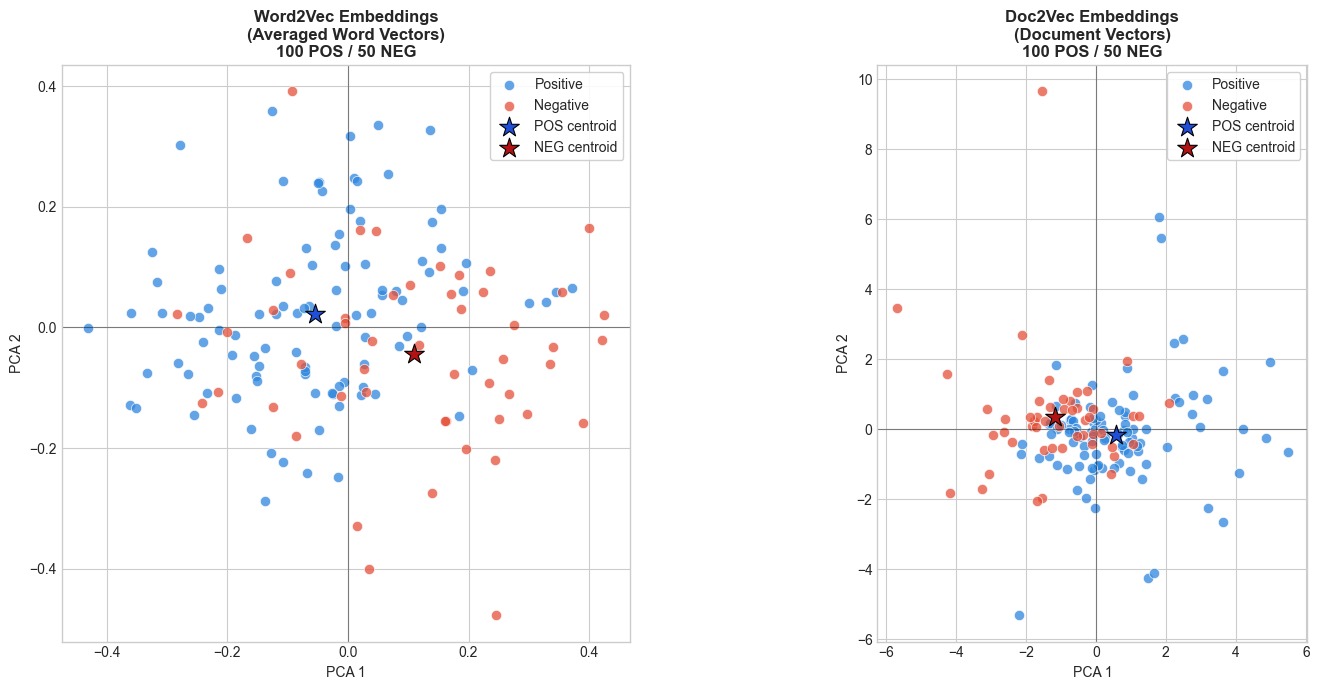


✓ Side-by-side comparison plot created successfully!
Word2Vec variance explained: 27.20%
Doc2Vec variance explained: 11.32%


In [17]:
# Train Word2Vec model for comparison
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

print("Training Word2Vec model for comparison...")
word2vec_model = Word2Vec(
    sentences=df['tokens'].values,
    vector_size=128,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)
print(f"Word2Vec model trained")
print(f"Vocabulary size: {len(word2vec_model.wv)}")

# Create averaged word vectors for Word2Vec
def get_avg_word2vec_vector(tokens, model, vector_size=128):
    vectors = []
    for token in tokens:
        if token in model.wv:
            vectors.append(model.wv[token])
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

X_word2vec = np.array([get_avg_word2vec_vector(tokens, word2vec_model, vector_size=128) for tokens in df['tokens']])
print(f"Word2Vec embeddings shape: {X_word2vec.shape}")

# Select same samples: 100 positive + 50 negative
pos_indices = df.index[df['sentiment'] == 1].to_numpy()
neg_indices = df.index[df['sentiment'] == 0].to_numpy()

pos_count = min(100, len(pos_indices))
neg_count = min(50, len(neg_indices))

rng = np.random.default_rng(42)
pos_sample = rng.choice(pos_indices, size=pos_count, replace=False)
neg_sample = rng.choice(neg_indices, size=neg_count, replace=False)

selected_indices = np.concatenate([pos_sample, neg_sample])
selected_labels = df.loc[selected_indices, 'sentiment'].to_numpy()

# Get vectors for both models
selected_word2vec = X_word2vec[selected_indices]
selected_doc2vec = X[selected_indices]

# Apply PCA to both
pca_w2v = PCA(n_components=2)
word2vec_2d = pca_w2v.fit_transform(selected_word2vec)

pca_d2v = PCA(n_components=2)
doc2vec_2d = pca_d2v.fit_transform(selected_doc2vec)

# Create side-by-side plot
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

pos_mask = selected_labels == 1
neg_mask = selected_labels == 0

# Plot 1: Word2Vec (Averaged Word Vectors)
ax1.scatter(word2vec_2d[pos_mask, 0], word2vec_2d[pos_mask, 1],
           s=55, c='#2e86de', alpha=0.75, edgecolors='white', linewidths=0.6,
           label='Positive')
ax1.scatter(word2vec_2d[neg_mask, 0], word2vec_2d[neg_mask, 1],
           s=55, c='#e55039', alpha=0.75, edgecolors='white', linewidths=0.6,
           label='Negative')

pos_centroid_w2v = word2vec_2d[pos_mask].mean(axis=0)
neg_centroid_w2v = word2vec_2d[neg_mask].mean(axis=0)

ax1.scatter(pos_centroid_w2v[0], pos_centroid_w2v[1], s=220, c='#1f4fd8',
           marker='*', edgecolors='black', linewidths=0.8, label='POS centroid')
ax1.scatter(neg_centroid_w2v[0], neg_centroid_w2v[1], s=220, c='#b31212',
           marker='*', edgecolors='black', linewidths=0.8, label='NEG centroid')

ax1.axhline(0, color='black', linewidth=0.8, alpha=0.4)
ax1.axvline(0, color='black', linewidth=0.8, alpha=0.4)
ax1.set_title(f'Word2Vec Embeddings\n(Averaged Word Vectors)\n100 POS / 50 NEG', fontweight='bold', fontsize=12)
ax1.set_xlabel('PCA 1')
ax1.set_ylabel('PCA 2')
ax1.set_aspect('equal', 'box')
ax1.legend(frameon=True, facecolor='white', framealpha=0.9)

# Plot 2: Doc2Vec (Document Vectors)
ax2.scatter(doc2vec_2d[pos_mask, 0], doc2vec_2d[pos_mask, 1],
           s=55, c='#2e86de', alpha=0.75, edgecolors='white', linewidths=0.6,
           label='Positive')
ax2.scatter(doc2vec_2d[neg_mask, 0], doc2vec_2d[neg_mask, 1],
           s=55, c='#e55039', alpha=0.75, edgecolors='white', linewidths=0.6,
           label='Negative')

pos_centroid_d2v = doc2vec_2d[pos_mask].mean(axis=0)
neg_centroid_d2v = doc2vec_2d[neg_mask].mean(axis=0)

ax2.scatter(pos_centroid_d2v[0], pos_centroid_d2v[1], s=220, c='#1f4fd8',
           marker='*', edgecolors='black', linewidths=0.8, label='POS centroid')
ax2.scatter(neg_centroid_d2v[0], neg_centroid_d2v[1], s=220, c='#b31212',
           marker='*', edgecolors='black', linewidths=0.8, label='NEG centroid')

ax2.axhline(0, color='black', linewidth=0.8, alpha=0.4)
ax2.axvline(0, color='black', linewidth=0.8, alpha=0.4)
ax2.set_title(f'Doc2Vec Embeddings\n(Document Vectors)\n100 POS / 50 NEG', fontweight='bold', fontsize=12)
ax2.set_xlabel('PCA 1')
ax2.set_ylabel('PCA 2')
ax2.set_aspect('equal', 'box')
ax2.legend(frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

print("\n✓ Side-by-side comparison plot created successfully!")
print(f"Word2Vec variance explained: {pca_w2v.explained_variance_ratio_.sum():.2%}")
print(f"Doc2Vec variance explained: {pca_d2v.explained_variance_ratio_.sum():.2%}")

## 7. Summary

In [18]:
# Summary
print("\n" + "=" * 70)
print("SENTIMENT ANALYSIS SUMMARY (Doc2Vec)")
print("=" * 70)
print(f"Dataset size: {len(df)} reviews")
print("Preprocessing: Lowercase, Remove HTML, Tokenize, Remove Stopwords, Lemmatize")
print("Embedding Method: Doc2Vec (one review = one doc)")
print("Classification Algorithm: Logistic Regression")
print("Train-Test Split: 80-20")
print(f"\nBest Metric: F1-Score = {f1:.4f}")
print("=" * 70)


SENTIMENT ANALYSIS SUMMARY (Doc2Vec)
Dataset size: 25000 reviews
Preprocessing: Lowercase, Remove HTML, Tokenize, Remove Stopwords, Lemmatize
Embedding Method: Doc2Vec (one review = one doc)
Classification Algorithm: Logistic Regression
Train-Test Split: 80-20

Best Metric: F1-Score = 0.8576
